# LM2500 response to AI data-center workload — torsional fatigue study

Drives a **single** LM2500 (22 MW class, GGOV1-controlled, two-mass GT + PT–gen torsional shaft) with a **2-hour facility power trace** derived from the MIT SuperCloud public dataset at native **100 ms cadence**.

**Goal:** observe how the governor and PT–gen shaft respond to 100 ms load transients, and quantify cumulative torsional fatigue (rainflow + Miner / Goodman) over the window. No baseline comparison run here — this notebook quantifies AI-workload damage on its own.

**Pipeline**

  MIT SuperCloud DCGM (100 ms) → facility MW trace → Tier C (GGOV1 + 2-mass GT) → Tier E (PT–gen torsional + rainflow + Miner)

**Time scales (preserved):**
- input load trace: 100 ms (10 Hz)
- Tier C output sample: 10 ms (resolves governor response between input steps)
- Tier E shaft ODE: 500 Hz (≈ 23× oversampling on the 22 Hz torsional mode)

In [1]:
import sys
from pathlib import Path

import boto3
from botocore import UNSIGNED
from botocore.config import Config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/Users/syellapa/Documents/Research/2026/DataCenter')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from gas_plant.dynamics.multishaft import simulate_multishaft, MultishaftParams
from gas_plant.dynamics.torsional import (
    compute_shaft_torques, TorsionalParams,
    detrend_rolling_median, rainflow_count, miners_damage,
)

## 1. Build the 2-hour, 100 ms facility power trace

Source: **MIT SuperCloud `nvidia_smi.csv`** — per-GPU power telemetry recorded every 100 ms (full file is 44 GB on S3). We fetch a contiguous 1 GB byte-range, aggregate concurrent GPU samples by timestamp, then pick the densest 2 h sub-window.

**Scaling:** the 1 GB sample only contains ~35 active GPUs (sub-kW native peak) — far too small to load an LM2500. We auto-calibrate `FACILITY_SCALE_MULTIPLIER` so the trace's post-PUE peak lands at `TARGET_PEAK_MW = 18 MW` (82% of LM2500 rated). The 100 ms variance and `dP/dt` shape — what excites the governor and torsional mode — are preserved verbatim; only the absolute MW level is calibrated. PUE = 1.25.

Note: nvidia_smi `id_job` does not join with the `scheduler_data.csv` / `dcgm.csv` job IDs (different anonymization), so we drive the trace from nvidia_smi alone.

In [2]:
NV_BYTES = 1_073_741_824  # 1 GB byte-range from nvidia_smi.csv
NV_CACHE = PROJECT_ROOT / 'data' / f'nvidia_smi_first_{NV_BYTES // (1024**3)}gb.parquet'
NV_CACHE.parent.mkdir(parents=True, exist_ok=True)

if NV_CACHE.exists():
    print(f'Loading cached subset: {NV_CACHE.name}')
    nv = pd.read_parquet(NV_CACHE)
else:
    print(f'Streaming first {NV_BYTES/1e9:.2f} GB of nvidia_smi.csv from open S3 ...')
    s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))
    obj = s3.get_object(
        Bucket='mit-supercloud-dataset',
        Key='2022-hpca/nvidia_smi.csv',
        Range=f'bytes=0-{NV_BYTES - 1}',
    )
    import io
    raw = obj['Body'].read()
    print(f'Downloaded {len(raw)/1e9:.2f} GB; parsing ...')
    nv = pd.read_csv(
        io.BytesIO(raw),
        usecols=['timestamp', 'power_draw_W', 'Node', 'gpu_index', 'id_job'],
        on_bad_lines='skip',  # last byte-range row may be partial
    )
    nv = nv.dropna(subset=['timestamp', 'power_draw_W']).copy()
    nv['timestamp'] = nv['timestamp'].astype(float)
    nv['power_draw_W'] = nv['power_draw_W'].astype(float)
    nv.to_parquet(NV_CACHE, index=False)
    print(f'Cached {len(nv):,} rows to {NV_CACHE.name}')

print(f'nvidia_smi subset: {len(nv):,} rows')
print(f'unique jobs:  {nv.id_job.nunique()}')
print(f'unique GPUs:  {nv.groupby(["Node", "gpu_index"]).ngroups}')
print(f'time span:    {pd.to_datetime(nv.timestamp.min(), unit="s")} -> {pd.to_datetime(nv.timestamp.max(), unit="s")}')
print(f'              ({(nv.timestamp.max() - nv.timestamp.min())/3600:.1f} h wall-clock spread)')

Loading cached subset: nvidia_smi_first_1gb.parquet


nvidia_smi subset: 11,684,187 rows
unique jobs:  50


unique GPUs:  35
time span:    2021-02-10 17:41:30.275000095 -> 2021-03-02 03:12:23.526000023
              (465.5 h wall-clock spread)


In [3]:
WINDOW_HOURS = 2.0
TARGET_PEAK_MW = 18.0  # 82% of LM2500 rated (22 MW) — exercises governor without saturation
PUE = 1.25             # cooling + transformer overhead

# --- Pick the densest 2 h sub-window (by GPU-sample count) ---
nv = nv.sort_values('timestamp').reset_index(drop=True)
ts = nv['timestamp'].values  # unix seconds, float

bin_s = 60.0
bins = np.arange(ts.min(), ts.max() + bin_s, bin_s)
counts, _ = np.histogram(ts, bins=bins)
win_bins = int(round(WINDOW_HOURS * 3600 / bin_s))
if win_bins >= len(counts):
    raise RuntimeError(f'Sample only spans {len(counts)*bin_s/3600:.1f} h, need >= {WINDOW_HOURS} h')
window_sum = np.convolve(counts, np.ones(win_bins, dtype=int), mode='valid')
best = int(np.argmax(window_sum))
W_start_unix = float(bins[best])
W_end_unix = W_start_unix + WINDOW_HOURS * 3600
print(f'Picked dense 2 h window:')
print(f'  start (UTC):  {pd.to_datetime(W_start_unix, unit="s")}')
print(f'  end   (UTC):  {pd.to_datetime(W_end_unix, unit="s")}')
print(f'  GPU samples in window: {int(window_sum[best]):,} (peak 60 s bin = {counts[best:best+win_bins].max()})')

# --- Subset rows and bin power to 100 ms slots ---
m = (ts >= W_start_unix) & (ts < W_end_unix)
sub = nv.loc[m, ['timestamp', 'power_draw_W']].copy()
sub['t_rel'] = sub['timestamp'] - W_start_unix
sub['slot'] = np.floor(sub['t_rel'] * 10.0).astype(np.int64)  # 100 ms slots
agg = sub.groupby('slot')['power_draw_W'].sum()
n_slots = int(WINDOW_HOURS * 3600 * 10)  # 72 000 slots
slot_idx = np.arange(n_slots, dtype=np.int64)
grid_w_native = agg.reindex(slot_idx, fill_value=0.0).values

# Fill short dropouts: treat zeros between samples as missing (ZOH carry-forward)
nonzero = grid_w_native > 0
if not nonzero.any():
    raise RuntimeError('Aggregated grid is all zero — pick a different byte range')
grid_w_native = pd.Series(np.where(nonzero, grid_w_native, np.nan)).ffill().bfill().values

# --- AUTO-CALIBRATE the facility scale multiplier so post-PUE peak = TARGET_PEAK_MW ---
# The native nvidia_smi 1 GB sample only covers ~35 GPUs at this point in time.
# To represent a multi-MW AI campus (orders of magnitude more GPUs), we scale up
# the trace SHAPE while pinning its absolute peak to a target loading level.
# This preserves all 100 ms variance and dP/dt characteristics — only the
# absolute MW level is calibrated.
native_peak_w = grid_w_native.max()
FACILITY_SCALE_MULTIPLIER = (TARGET_PEAK_MW * 1e6) / (native_peak_w * PUE)
print(f'\nAuto-calibration:')
print(f'  native peak  : {native_peak_w/1e3:.2f} kW  (sum across {nv.loc[m].groupby(["Node","gpu_index"]).ngroups} GPUs in window)')
print(f'  multiplier   : {FACILITY_SCALE_MULTIPLIER:,.0f}x   (effective number of equivalent clusters)')
print(f'  PUE          : {PUE}')
print(f'  target peak  : {TARGET_PEAK_MW:.1f} MW  ({TARGET_PEAK_MW/22.0*100:.0f}% of LM2500 rated)')

facility_w = grid_w_native * FACILITY_SCALE_MULTIPLIER * PUE
p_mw = facility_w / 1e6
t_sec = slot_idx / 10.0
dpdt = np.diff(p_mw) / np.diff(t_sec)

print(f'\nTrace: {len(t_sec):,} samples @ 100 ms over {t_sec[-1]/3600 + 0.0001:.2f} h')
print(f'Power MW:  min={p_mw.min():.2f}  mean={p_mw.mean():.2f}  max={p_mw.max():.2f}')
print(f'|dP/dt| MW/s:  max={np.abs(dpdt).max():.2f}  p99={np.percentile(np.abs(dpdt), 99):.2f}  p50={np.percentile(np.abs(dpdt), 50):.3f}')

Picked dense 2 h window:
  start (UTC):  2021-02-22 12:40:30.275000095
  end   (UTC):  2021-02-22 14:40:30.275000095
  GPU samples in window: 394,761 (peak 60 s bin = 3322)

Auto-calibration:
  native peak  : 1.40 kW  (sum across 6 GPUs in window)
  multiplier   : 10,298x   (effective number of equivalent clusters)
  PUE          : 1.25
  target peak  : 18.0 MW  (82% of LM2500 rated)

Trace: 72,000 samples @ 100 ms over 2.00 h
Power MW:  min=0.60  mean=8.84  max=18.00
|dP/dt| MW/s:  max=157.80  p99=87.62  p50=19.526


Anchor event at t = 1207.00 s  (|dP/dt| = 157.80 MW/s)
Zoom window: 1192.00 -> 1222.00 s


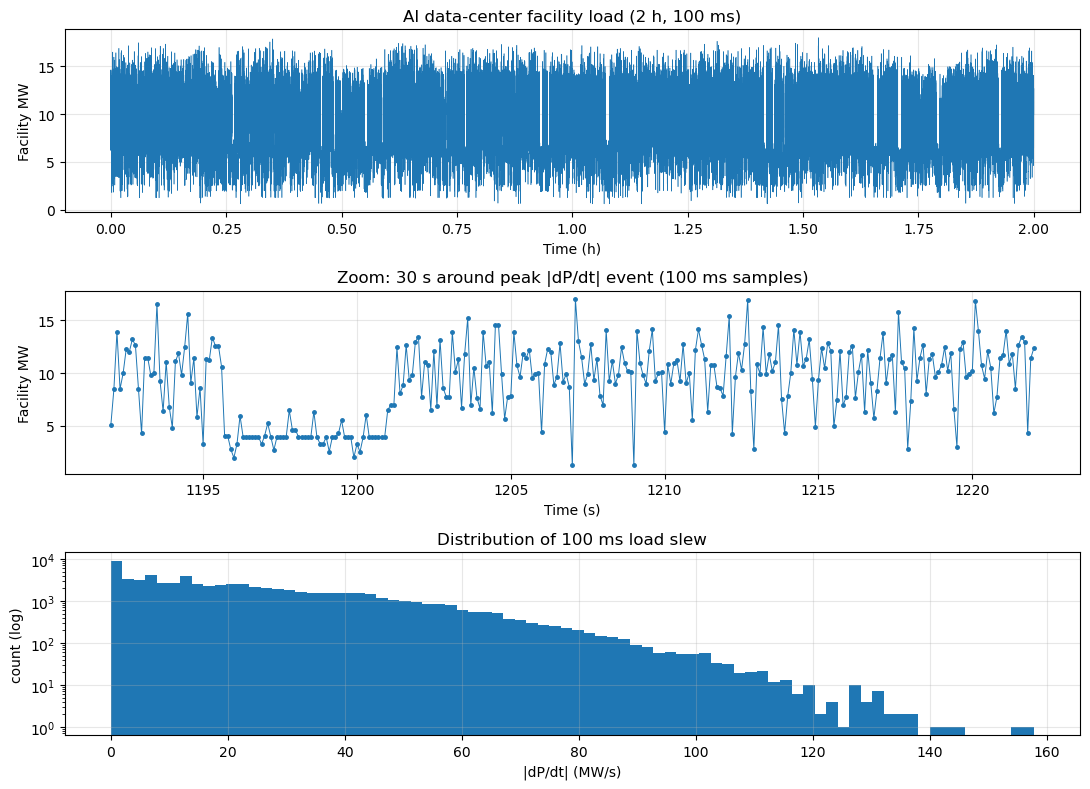

In [4]:
i_event = int(np.argmax(np.abs(dpdt)))
zoom_w = 30.0
zoom_lo = max(0.0, t_sec[i_event] - zoom_w / 2)
zoom_hi = zoom_lo + zoom_w
print(f'Anchor event at t = {t_sec[i_event]:.2f} s  (|dP/dt| = {np.abs(dpdt).max():.2f} MW/s)')
print(f'Zoom window: {zoom_lo:.2f} -> {zoom_hi:.2f} s')

fig, axes = plt.subplots(3, 1, figsize=(11, 8))
axes[0].plot(t_sec / 3600.0, p_mw, lw=0.4)
axes[0].set(xlabel='Time (h)', ylabel='Facility MW', title='AI data-center facility load (2 h, 100 ms)')
axes[0].grid(alpha=0.3)

zm = (t_sec >= zoom_lo) & (t_sec <= zoom_hi)
axes[1].plot(t_sec[zm], p_mw[zm], 'o-', ms=2.5, lw=0.7)
axes[1].set(xlabel='Time (s)', ylabel='Facility MW',
            title='Zoom: 30 s around peak |dP/dt| event (100 ms samples)')
axes[1].grid(alpha=0.3)

axes[2].hist(np.abs(dpdt), bins=80, log=True)
axes[2].set(xlabel='|dP/dt| (MW/s)', ylabel='count (log)', title='Distribution of 100 ms load slew')
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Tier C — single LM2500 governor + 2-mass GT response

Single unit at default ratings: `P_turbine_mw = 22 MW`, `Sn_mva = 23`. Demand is passed as raw MW (ZOH internally). `sample_dt_s = 0.01` so the output grid resolves governor response between consecutive 100 ms load steps.

_This call performs ~72 000 `solve_ivp` invocations (one per input step); expect a few minutes of wall time._

In [5]:
mps_params = MultishaftParams()
print(f'GGOV1 base MVA = {mps_params.ggov1.Sn_mva}')
print(f'GGOV1 turbine rated MW = {mps_params.ggov1.P_turbine_mw}')
print(f'Peak demand / rated = {p_mw.max() / mps_params.ggov1.P_turbine_mw:.2%}')

r = simulate_multishaft(t_sec, p_mw, params=mps_params, sample_dt_s=0.01)
print(f'Tier C output: {r.t_s.size:,} samples @ 10 ms')
print(f'freq:  min={r.freq_hz.min():.3f}  max={r.freq_hz.max():.3f} Hz')
print(f'valve: min={r.valve_pu.min():.3f}  max={r.valve_pu.max():.3f} pu')
print(f'omega_pt: min={r.omega_pt_pu.min():.4f}  max={r.omega_pt_pu.max():.4f} pu')
print(f'omega_hp: min={r.omega_hp_pu.min():.4f}  max={r.omega_hp_pu.max():.4f} pu')

GGOV1 base MVA = 23.0
GGOV1 turbine rated MW = 22.0
Peak demand / rated = 81.82%


Tier C output: 719,991 samples @ 10 ms
freq:  min=44.790  max=67.250 Hz
valve: min=0.150  max=0.671 pu
omega_pt: min=0.7465  max=1.1208 pu
omega_hp: min=-0.4824  max=0.8347 pu


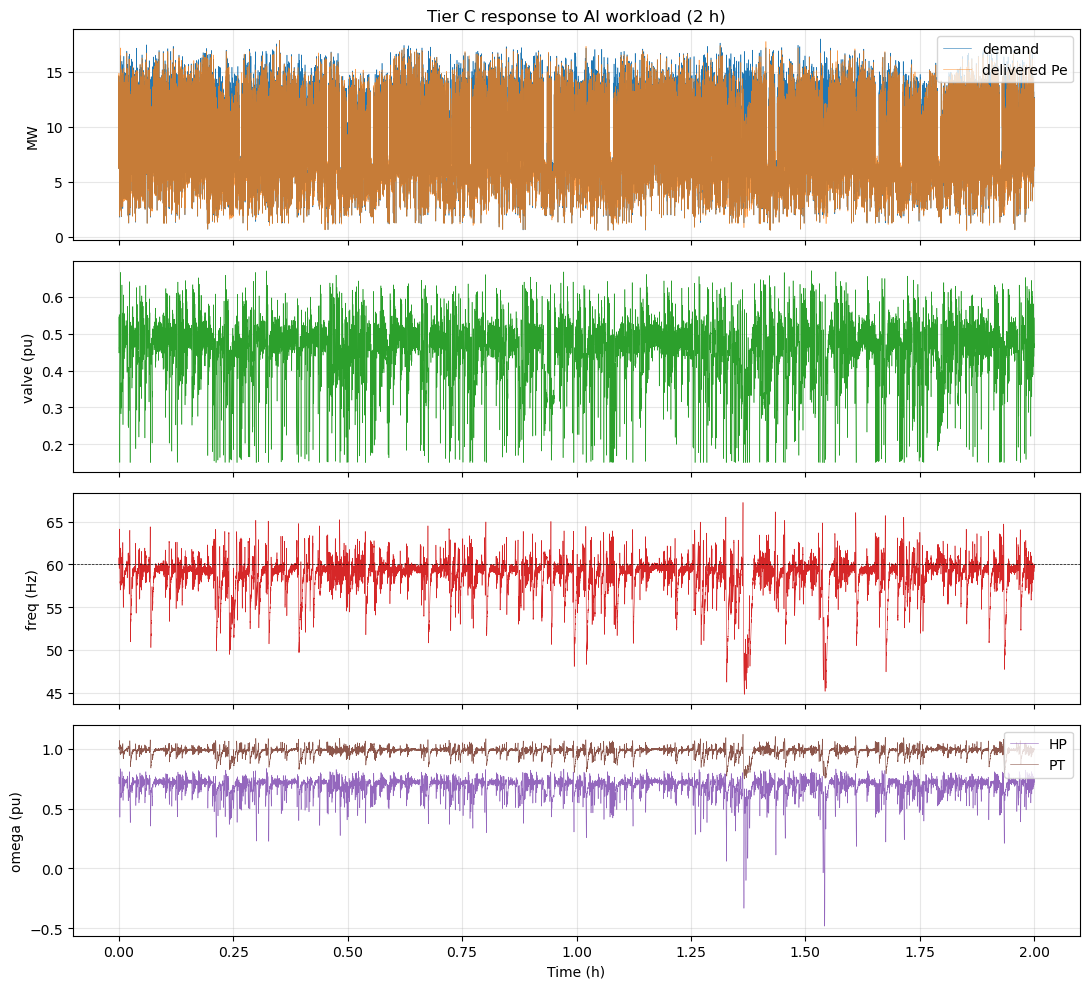

In [6]:
t_h = r.t_s / 3600.0
fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)

axes[0].plot(t_h, r.Pe_demand_mw, lw=0.4, label='demand')
axes[0].plot(t_h, r.Pe_mw, lw=0.4, label='delivered Pe', alpha=0.75)
axes[0].set_ylabel('MW'); axes[0].legend(loc='upper right'); axes[0].grid(alpha=0.3)
axes[0].set_title('Tier C response to AI workload (2 h)')

axes[1].plot(t_h, r.valve_pu, lw=0.4, color='C2')
axes[1].set_ylabel('valve (pu)'); axes[1].grid(alpha=0.3)

axes[2].plot(t_h, r.freq_hz, lw=0.4, color='C3')
axes[2].axhline(60.0, color='k', lw=0.5, ls='--')
axes[2].set_ylabel('freq (Hz)'); axes[2].grid(alpha=0.3)

axes[3].plot(t_h, r.omega_hp_pu, lw=0.4, color='C4', label='HP')
axes[3].plot(t_h, r.omega_pt_pu, lw=0.4, color='C5', label='PT')
axes[3].set_ylabel('omega (pu)'); axes[3].set_xlabel('Time (h)')
axes[3].legend(loc='upper right'); axes[3].grid(alpha=0.3)
plt.tight_layout()
plt.show()

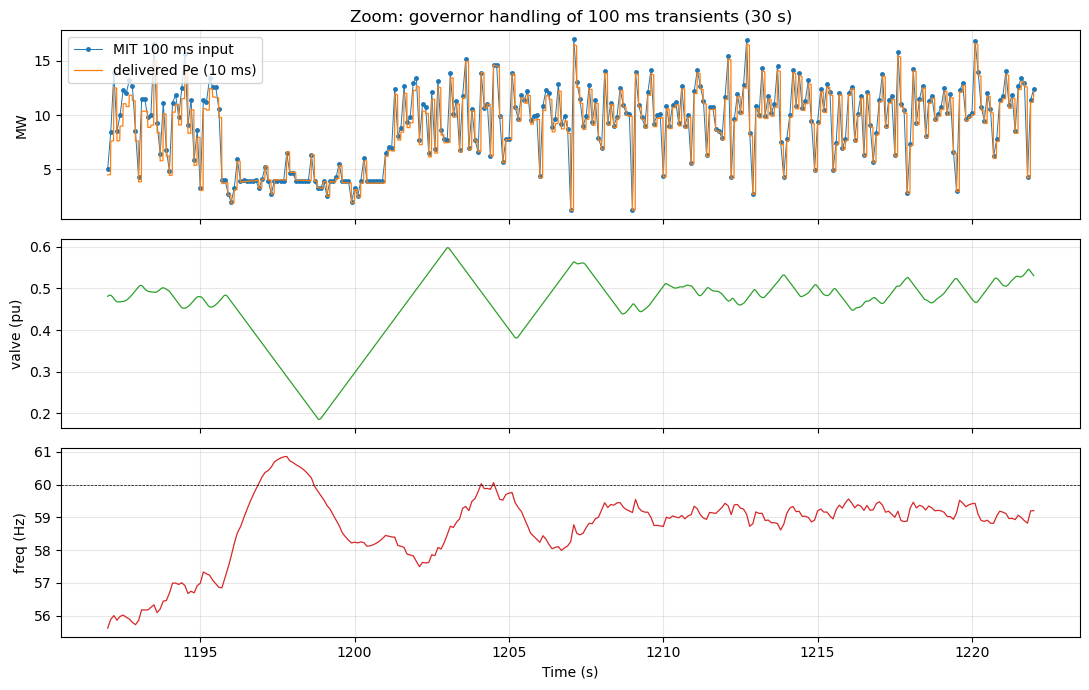

In [7]:
zm_r = (r.t_s >= zoom_lo) & (r.t_s <= zoom_hi)
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

axes[0].plot(t_sec[zm], p_mw[zm], 'o-', ms=2.5, lw=0.7, label='MIT 100 ms input')
axes[0].plot(r.t_s[zm_r], r.Pe_mw[zm_r], lw=0.9, label='delivered Pe (10 ms)')
axes[0].set_ylabel('MW'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Zoom: governor handling of 100 ms transients (30 s)')

axes[1].plot(r.t_s[zm_r], r.valve_pu[zm_r], lw=0.9, color='C2')
axes[1].set_ylabel('valve (pu)'); axes[1].grid(alpha=0.3)

axes[2].plot(r.t_s[zm_r], r.freq_hz[zm_r], lw=0.9, color='C3')
axes[2].axhline(60.0, color='k', lw=0.5, ls='--')
axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('freq (Hz)'); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Tier E — PT–gen torsional shaft

Two-mass model (PT rotor ↔ generator rotor coupled through the physical PT–gen shaft). Driven by Tier C's `Pm_pt_mw` (mechanical input from gas-path coupling) and `Pe_mw` (electrical load torque). Common-mode speed `omega_pt` is taken externally from Tier C (Tier E v2 fix). Solved at 500 Hz over the full 2 h window.

In [8]:
SHAFT_FS_HZ = 500.0
tor_params = TorsionalParams()
print(f'Torsional mode f_n = {tor_params.f_torsion_hz} Hz, zeta = {tor_params.zeta_torsion*100:.1f} %')
print(f'Sampling at {SHAFT_FS_HZ} Hz -> {SHAFT_FS_HZ/tor_params.f_torsion_hz:.1f}x oversampling on the mode')
print(f'Shaft: {tor_params.shaft_diameter_mm} mm OD / {tor_params.shaft_inner_mm} mm ID, {tor_params.shaft_steel}')

shaft = compute_shaft_torques(r, params=tor_params, sample_rate_hz=SHAFT_FS_HZ)
T = shaft['T_shaft_kNm']
t_sh = shaft['t']
print(f'Shaft torque kN.m: min={T.min():.2f}  max={T.max():.2f}  mean={T.mean():.2f}  std={T.std():.3f}')

Torsional mode f_n = 22.0 Hz, zeta = 1.0 %
Sampling at 500.0 Hz -> 22.7x oversampling on the mode
Shaft: 150.0 mm OD / 50.0 mm ID, AISI 4340


Shaft torque kN.m: min=-4.85  max=44.71  mean=21.92  std=7.818


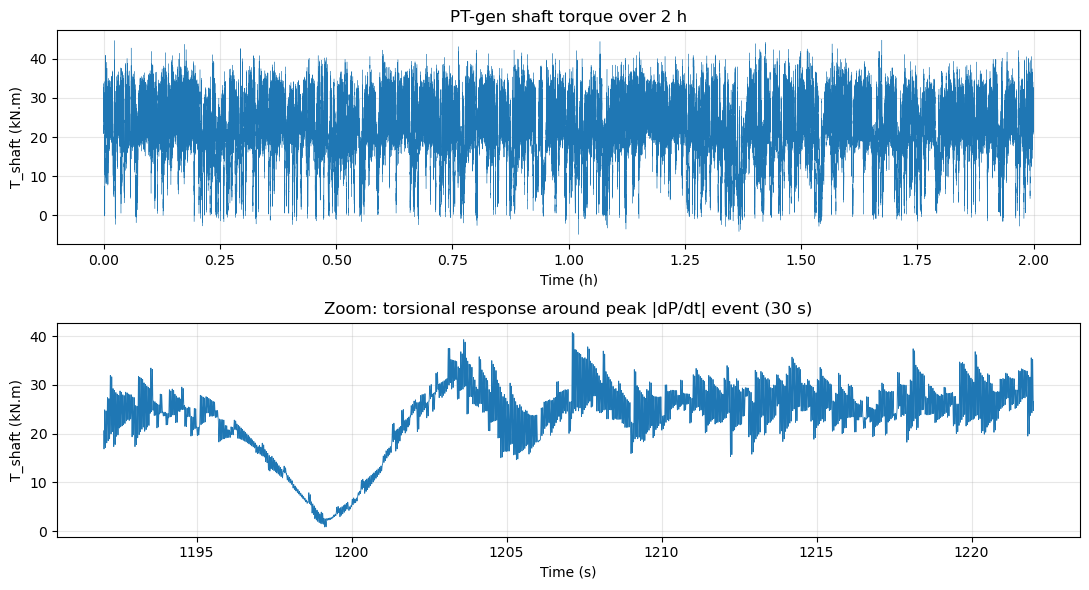

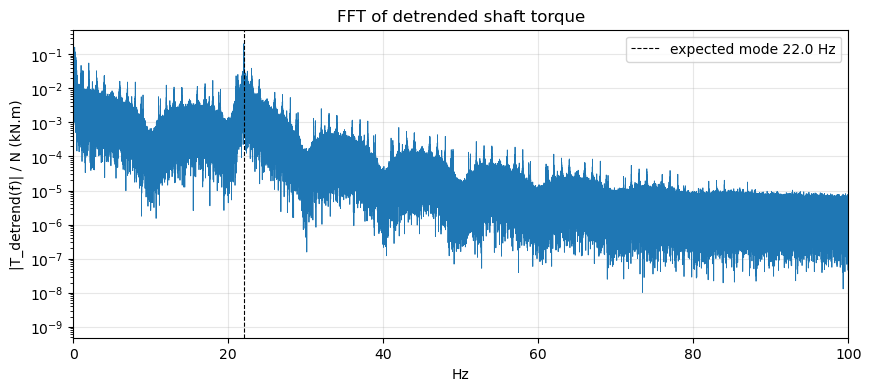

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6))
axes[0].plot(t_sh / 3600.0, T, lw=0.25)
axes[0].set(xlabel='Time (h)', ylabel='T_shaft (kN.m)', title='PT-gen shaft torque over 2 h')
axes[0].grid(alpha=0.3)

zm_sh = (t_sh >= zoom_lo) & (t_sh <= zoom_hi)
axes[1].plot(t_sh[zm_sh], T[zm_sh], lw=0.6)
axes[1].set(xlabel='Time (s)', ylabel='T_shaft (kN.m)',
            title=f'Zoom: torsional response around peak |dP/dt| event ({zoom_w:.0f} s)')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

T_detrend, _ = detrend_rolling_median(T, t_sh, window_s=5.0)
N = T_detrend.size
freqs = np.fft.rfftfreq(N, d=1.0/SHAFT_FS_HZ)
mag = np.abs(np.fft.rfft(T_detrend)) / N
plt.figure(figsize=(10, 4))
plt.semilogy(freqs, mag, lw=0.6)
plt.axvline(tor_params.f_torsion_hz, color='k', ls='--', lw=0.8,
            label=f'expected mode {tor_params.f_torsion_hz} Hz')
plt.xlim(0, 100); plt.xlabel('Hz'); plt.ylabel('|T_detrend(f)| / N (kN.m)')
plt.legend(); plt.title('FFT of detrended shaft torque'); plt.grid(alpha=0.3)
plt.show()

## 4. Fatigue — HCF (residual) + LCF (bulk trend)

5 s rolling-median detrending splits the shaft torque into two **disjoint frequency bands**:

- **HCF (high-cycle)** — the 22 Hz torsional-mode oscillation in the residual. Rainflow + Basquin S-N + Goodman mean-stress correction with `m=9`, `N_ref=1e8 at 300 MPa` (endurance regime, AISI 4340).
- **LCF (low-cycle)** — the slow governor-driven torque excursions (tens of kN·m, sub-Hz) in the bulk trend. Each excursion is a damaging cycle in the plastic-strain regime; we apply a steeper S-N curve appropriate for high-strength steel LCF: `m=4`, `N_ref=1e4 at 500 MPa` (≈ 0.5 × UTS). Rainflow on `T_trend` directly.

Total cumulative damage `D = D_HCF + D_LCF`. The two bands cannot double-count: residual is > 0.2 Hz (passes the 5 s median's high-pass), trend is < 0.2 Hz.

In [10]:
T_res, T_trend = detrend_rolling_median(T, t_sh, window_s=5.0)
print(f'Bulk trend kN.m: min={T_trend.min():.2f}  max={T_trend.max():.2f}')
print(f'Residual kN.m:   std={T_res.std():.3f}  max|res|={np.abs(T_res).max():.2f}')

# --- HCF: rainflow on the high-frequency residual ---
cycles_hcf = rainflow_count(T_res, t_sh)
cycles_hcf = miners_damage(cycles_hcf, tor_params, use_goodman=True)
D_hcf = float(cycles_hcf['d_i'].sum())
print(f'\n[HCF] params: m={tor_params.m_fatigue}, N_ref={tor_params.N_ref:.0e} at Sa_ref={tor_params.Sa_ref_mpa:.0f} MPa')
print(f'      cycles: {len(cycles_hcf):,}')
if len(cycles_hcf):
    print(f'      Sa_eq MPa  min/med/max: {cycles_hcf["Sa_eq_mpa"].min():.2f} / {cycles_hcf["Sa_eq_mpa"].median():.2f} / {cycles_hcf["Sa_eq_mpa"].max():.2f}')
print(f'      D_HCF = {D_hcf:.3e}')

# --- LCF: rainflow on the bulk-trend signal ---
# Each governor-driven torque excursion (tens of kN.m, sub-Hz) is a low-cycle event.
# Steeper S-N curve appropriate for plastic-strain regime in high-strength steel:
#   m = 4, N_ref = 1e4 cycles at Sa_ref = 500 MPa (~0.5 * UTS for AISI 4340).
# Disjoint in frequency from HCF (residual > 0.2 Hz, trend < 0.2 Hz) — no double-counting.
lcf_params = TorsionalParams(m_fatigue=4.0, N_ref=1e4, Sa_ref_mpa=500.0)
cycles_lcf = rainflow_count(T_trend, t_sh)
cycles_lcf = miners_damage(cycles_lcf, lcf_params, use_goodman=True)
D_lcf = float(cycles_lcf['d_i'].sum())
print(f'\n[LCF] params: m={lcf_params.m_fatigue}, N_ref={lcf_params.N_ref:.0e} at Sa_ref={lcf_params.Sa_ref_mpa:.0f} MPa')
print(f'      cycles: {len(cycles_lcf):,}')
if len(cycles_lcf):
    print(f'      Sa_eq MPa  min/med/max: {cycles_lcf["Sa_eq_mpa"].min():.2f} / {cycles_lcf["Sa_eq_mpa"].median():.2f} / {cycles_lcf["Sa_eq_mpa"].max():.2f}')
print(f'      D_LCF = {D_lcf:.3e}')

# --- Combine ---
D_window = D_hcf + D_lcf
WINDOW_SEC = float(t_sh[-1])
years_per_window = WINDOW_SEC / (365.25 * 24 * 3600)
D_per_year = D_window / years_per_window if years_per_window > 0 else 0.0
years_to_failure = (1.0 / D_per_year) if D_per_year > 0 else float('inf')
lcf_hcf_ratio = D_lcf / D_hcf if D_hcf > 0 else float('inf')
print(f'\n[TOTAL] D_window = D_HCF + D_LCF = {D_window:.3e}   (LCF/HCF = {lcf_hcf_ratio:.2e})')
print(f'        D per year equivalent = {D_per_year:.3e}')
print(f'        Years to D=1          = {years_to_failure:.2f}')

# Keep `cycles` pointing at HCF for back-compat with existing references
cycles = cycles_hcf

Bulk trend kN.m: min=1.98  max=31.14
Residual kN.m:   std=3.720  max|res|=18.20



[HCF] params: m=9.0, N_ref=1e+08 at Sa_ref=300 MPa
      cycles: 159,580
      Sa_eq MPa  min/med/max: 0.00 / 3.21 / 26.85
      D_HCF = 1.003e-16



[LCF] params: m=4.0, N_ref=1e+04 at Sa_ref=500 MPa
      cycles: 22,758
      Sa_eq MPa  min/med/max: 0.00 / 0.01 / 23.26
      D_LCF = 1.784e-08

[TOTAL] D_window = D_HCF + D_LCF = 1.784e-08   (LCF/HCF = 1.78e+08)
        D per year equivalent = 7.821e-05
        Years to D=1          = 12786.58


/var/folders/3t/dnxcpb1d6fx7bhfv9qyhfl4cg9pqnk/T/ipykernel_51715/2719202392.py:41: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


/Users/syellapa/miniconda3/envs/datacenter/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


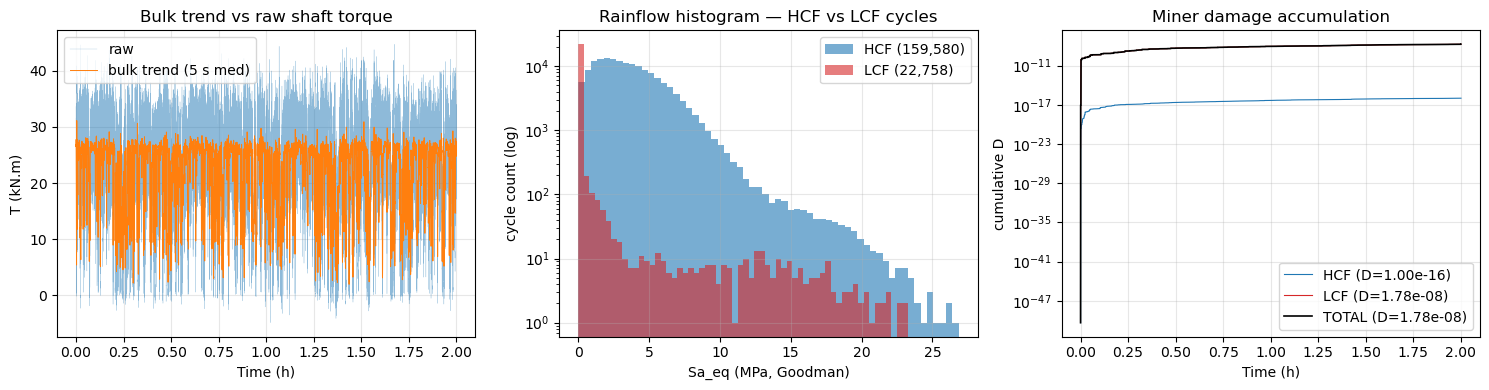

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# col 0: bulk trend vs raw shaft torque
axes[0].plot(t_sh / 3600.0, T, lw=0.2, alpha=0.5, label='raw')
axes[0].plot(t_sh / 3600.0, T_trend, lw=0.7, label='bulk trend (5 s med)')
axes[0].set(xlabel='Time (h)', ylabel='T (kN.m)', title='Bulk trend vs raw shaft torque')
axes[0].legend(); axes[0].grid(alpha=0.3)

# col 1: HCF + LCF rainflow histograms on the same axes
if len(cycles_hcf):
    axes[1].hist(cycles_hcf['Sa_eq_mpa'], bins=60, log=True, alpha=0.6, label=f'HCF ({len(cycles_hcf):,})')
if len(cycles_lcf):
    axes[1].hist(cycles_lcf['Sa_eq_mpa'], bins=60, log=True, alpha=0.6, color='C3', label=f'LCF ({len(cycles_lcf):,})')
axes[1].set(xlabel='Sa_eq (MPa, Goodman)', ylabel='cycle count (log)',
            title='Rainflow histogram — HCF vs LCF cycles')
axes[1].legend(); axes[1].grid(alpha=0.3)

# col 2: cumulative D — HCF, LCF, total
def cumD(cdf):
    if len(cdf) == 0:
        return np.array([0.0]), np.array([0.0])
    s = cdf.sort_values('t_close')[['t_close', 'd_i']].copy()
    return s['t_close'].values / 3600.0, s['d_i'].cumsum().values

t_h_hcf, D_hcf_cum = cumD(cycles_hcf)
t_h_lcf, D_lcf_cum = cumD(cycles_lcf)
axes[2].plot(t_h_hcf, D_hcf_cum, lw=0.8, label=f'HCF (D={D_hcf:.2e})')
axes[2].plot(t_h_lcf, D_lcf_cum, lw=0.8, color='C3', label=f'LCF (D={D_lcf:.2e})')
# Total: merge on time
all_pts = pd.concat([
    pd.DataFrame({'t': cycles_hcf['t_close'].values / 3600.0, 'd': cycles_hcf['d_i'].values}) if len(cycles_hcf) else pd.DataFrame(columns=['t','d']),
    pd.DataFrame({'t': cycles_lcf['t_close'].values / 3600.0, 'd': cycles_lcf['d_i'].values}) if len(cycles_lcf) else pd.DataFrame(columns=['t','d']),
]).sort_values('t')
if len(all_pts):
    axes[2].plot(all_pts['t'].values, all_pts['d'].cumsum().values, lw=1.2, color='k', label=f'TOTAL (D={D_window:.2e})')
axes[2].set(xlabel='Time (h)', ylabel='cumulative D',
            title='Miner damage accumulation')
axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

## 5. Summary

In [12]:
summary = pd.DataFrame([{
    'window_hours': WINDOW_HOURS,
    'input_samples_100ms': int(len(t_sec)),
    'peak_facility_mw': float(p_mw.max()),
    'mean_facility_mw': float(p_mw.mean()),
    'max_abs_dpdt_mw_per_s': float(np.abs(dpdt).max()),
    'p99_abs_dpdt_mw_per_s': float(np.percentile(np.abs(dpdt), 99)),
    'freq_max_excursion_hz': float(max(60.0 - r.freq_hz.min(), r.freq_hz.max() - 60.0)),
    'valve_max_pu': float(r.valve_pu.max()),
    'peak_shaft_torque_kNm': float(np.abs(T).max()),
    'shaft_residual_std_kNm': float(T_res.std()),
    'hcf_cycles': int(len(cycles_hcf)),
    'lcf_cycles': int(len(cycles_lcf)),
    'D_HCF': D_hcf,
    'D_LCF': D_lcf,
    'D_total_window': D_window,
    'LCF_over_HCF_ratio': lcf_hcf_ratio,
    'D_per_year_eq': D_per_year,
    'years_to_failure': years_to_failure,
}]).T.rename(columns={0: 'value'})
summary

,value
window_hours,2.000000e+00
input_samples_100ms,7.200000e+04
peak_facility_mw,1.800000e+01
mean_facility_mw,8.842886e+00
max_abs_dpdt_mw_per_s,1.578017e+02
p99_abs_dpdt_mw_per_s,8.761679e+01
freq_max_excursion_hz,1.521035e+01
valve_max_pu,6.710193e-01
peak_shaft_torque_kNm,4.471209e+01
shaft_residual_std_kNm,3.719906e+00


## Caveats

- **MIT trace is bottom-up scaled.** 1 GB sample of `nvidia_smi.csv` had ~35 active GPUs in the 2 h window (sub-kW native peak). The trace shape (100 ms variance, `dP/dt`) is genuine; the absolute MW level is **auto-calibrated** to `TARGET_PEAK_MW = 18 MW` via `FACILITY_SCALE_MULTIPLIER`. Different `TARGET_PEAK_MW` values rescale the fatigue numbers but not the qualitative dynamics.
- **No baseline / comparison** included — this notebook quantifies AI-workload damage alone.
- **Years-to-failure** assumes a full year of operation identical to this 2 h window; real duty cycles will differ.
- **Thermal transients not modeled** — combustion heat-soak and PT blade-row transient effects are out of scope; Tier C/E use quasi-steady aerothermodynamics.
- **Single unit only.** A fleet (N units sharing load) would see proportionally lower per-unit damage — a follow-on study.
- **`nvidia_smi.csv` vs `scheduler_data.csv` job IDs do not join** (different anonymization). The trace is driven from nvidia_smi telemetry alone.